# Route Geometry and Identification

This experiment measures each WR's observed, field-normalized path from snap through pass release. The continuous geometry features condition the separation benchmark on the realized route shape, so this is retrospective, not a snap-time prediction. The dataset marks who ran a route but contains no canonical route-type label.

Separately, we cluster 11-point, start-relative path curves for visualization only. Cluster IDs are latent shape groups; they are neither named football routes nor predictors in the SOE model.

In [2]:
from pathlib import Path
import json
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
from separation_over_expected.feature_schema import ROUTE_GEOMETRY_FEATURES, ROUTE_SHAPE_COLUMN
from separation_over_expected.reports import read_csv_rows

EXPERIMENT_DIR = PROJECT_ROOT / "data" / "processed" / "dynamic_features" / "route_geometry"
ROUTES = read_csv_rows(EXPERIMENT_DIR / "route_level_snap_to_release_geometry.csv")
METRICS = read_csv_rows(EXPERIMENT_DIR / "cross_validation" / "oof_metrics_wr.csv")
RELIABILITY = read_csv_rows(EXPERIMENT_DIR / "cross_validation" / "receiver_oof_reliability_wr.csv")
CLUSTER_DIR = EXPERIMENT_DIR / "clusters"
CLUSTER_METRICS = read_csv_rows(CLUSTER_DIR / "route_family_metrics_wr.csv")
CLUSTER_SUMMARIES = read_csv_rows(CLUSTER_DIR / "route_family_summaries_wr.csv")
len(ROUTES), len(METRICS), len(RELIABILITY), len(CLUSTER_METRICS)

(35032, 18, 5, 8)

## Data and feature checks

The route table has one row per route runner. The geometric features use only that receiver's trajectory between the snap and release events; shape coordinates are relative to the snap point and sampled at 11 equally spaced time fractions.

In [4]:
feature_coverage = {
    "route_rows": len(ROUTES),
    "unique_route_keys": len({(row["gameId"], row["playId"], row["nflId"]) for row in ROUTES}),
    "geometry_features": len(ROUTE_GEOMETRY_FEATURES),
    "missing_by_feature": {
        feature: sum(row.get(feature, "") == "" for row in ROUTES)
        for feature in ROUTE_GEOMETRY_FEATURES
    },
    "shape_point_counts": sorted({len(json.loads(row[ROUTE_SHAPE_COLUMN])) for row in ROUTES}),
}
feature_coverage

{'route_rows': 35032, 'unique_route_keys': 35032, 'geometry_features': 10, 'missing_by_feature': {'route_path_length_pre_release': 0, 'route_chord_length_pre_release': 0, 'route_directness_pre_release': 0, 'route_depth_excursion_max_pre_release': 0, 'route_depth_excursion_min_pre_release': 0, 'route_lateral_excursion_max_pre_release': 0, 'route_lateral_excursion_min_pre_release': 0, 'route_cumulative_turn_degrees_pre_release': 0, 'route_max_turn_degrees_pre_release': 0, 'route_max_chord_deviation_pre_release': 0}, 'shape_point_counts': [11]}

## Route-level out-of-fold prediction

Each model predicts WR separation change on games excluded from its training fold. Static and dynamic results should match the previous experiment exactly; the geometry model adds ten trajectory summaries to the existing dynamic ridge model.

In [6]:
OOF = [row for row in METRICS if row["fold"] == "OOF_ALL"]
FOLD_RESULTS = [row for row in METRICS if row["fold"] != "OOF_ALL"]
OOF, FOLD_RESULTS

([{'fold': 'OOF_ALL', 'model': 'ridge_context', 'mae': '1.390', 'rmse': '1.897', 'r2': '0.493', 'bias': '0.001', 'mean_actual': '-2.341', 'mean_predicted': '-2.341', 'n': '20415'}, {'fold': 'OOF_ALL', 'model': 'ridge_dynamic_context', 'mae': '1.363', 'rmse': '1.869', 'r2': '0.508', 'bias': '0.001', 'mean_actual': '-2.341', 'mean_predicted': '-2.342', 'n': '20415'}, {'fold': 'OOF_ALL', 'model': 'ridge_dynamic_geometry_context', 'mae': '1.304', 'rmse': '1.749', 'r2': '0.569', 'bias': '0.001', 'mean_actual': '-2.341', 'mean_predicted': '-2.342', 'n': '20415'}], [{'fold': '1', 'model': 'ridge_context', 'mae': '1.363', 'rmse': '1.853', 'r2': '0.496', 'bias': '0.011', 'mean_actual': '-2.276', 'mean_predicted': '-2.287', 'n': '4972'}, {'fold': '1', 'model': 'ridge_dynamic_context', 'mae': '1.335', 'rmse': '1.826', 'r2': '0.511', 'bias': '0.011', 'mean_actual': '-2.276', 'mean_predicted': '-2.287', 'n': '4972'}, {'fold': '1', 'model': 'ridge_dynamic_geometry_context', 'mae': '1.276', 'rmse': '

## Receiver score reliability

Reliability is the correlation of each eligible receiver's mean out-of-fold SOE between two disjoint, week-balanced game halves. These 115 receivers each have at least 20 WR routes per half. The paired bootstrap difference uses the same receivers for the two models.

In [8]:
RELIABILITY

[{'comparison': 'ridge_context', 'eligible_receivers': '115', 'pearson': '0.430880', 'spearman': '0.220556', 'pearson_ci_lower': '0.071785', 'pearson_ci_upper': '0.672905', 'spearman_ci_lower': '0.032200', 'spearman_ci_upper': '0.386949', 'minimum_routes_each_half': '20'}, {'comparison': 'ridge_dynamic_context', 'eligible_receivers': '115', 'pearson': '0.451857', 'spearman': '0.209469', 'pearson_ci_lower': '0.079452', 'pearson_ci_upper': '0.691667', 'spearman_ci_lower': '0.022494', 'spearman_ci_upper': '0.384713', 'minimum_routes_each_half': '20'}, {'comparison': 'ridge_dynamic_geometry_context', 'eligible_receivers': '115', 'pearson': '0.261958', 'spearman': '0.188929', 'pearson_ci_lower': '0.014585', 'pearson_ci_upper': '0.471523', 'spearman_ci_lower': '-0.006428', 'spearman_ci_upper': '0.365256', 'minimum_routes_each_half': '20'}, {'comparison': 'dynamic_minus_static', 'eligible_receivers': '115', 'pearson': '0.020977', 'spearman': '-0.011087', 'pearson_ci_lower': '-0.032642', 'pear

## Unlabeled route-family exploration

K-means runs on the standardized 20 coordinates (10 relative depth/lateral pairs after the fixed origin) for candidate k values 3–10. Silhouette is averaged over four seeded fits; mean pairwise adjusted Rand index (ARI) reports assignment stability across those fits. The selected k maximizes mean silhouette. No canonical route names are assigned.

In [10]:
CLUSTER_METRICS

[{'position': 'WR', 'n_routes': '20415', 'n_clusters': '3', 'mean_silhouette': '0.371981', 'silhouette_sd': '0.012081', 'mean_pairwise_ari': '0.945717', 'selected': 'false'}, {'position': 'WR', 'n_routes': '20415', 'n_clusters': '4', 'mean_silhouette': '0.409078', 'silhouette_sd': '0.055665', 'mean_pairwise_ari': '0.604451', 'selected': 'true'}, {'position': 'WR', 'n_routes': '20415', 'n_clusters': '5', 'mean_silhouette': '0.342079', 'silhouette_sd': '0.000000', 'mean_pairwise_ari': '1.000000', 'selected': 'false'}, {'position': 'WR', 'n_routes': '20415', 'n_clusters': '6', 'mean_silhouette': '0.324346', 'silhouette_sd': '0.001550', 'mean_pairwise_ari': '0.871522', 'selected': 'false'}, {'position': 'WR', 'n_routes': '20415', 'n_clusters': '7', 'mean_silhouette': '0.311088', 'silhouette_sd': '0.000401', 'mean_pairwise_ari': '0.986465', 'selected': 'false'}, {'position': 'WR', 'n_routes': '20415', 'n_clusters': '8', 'mean_silhouette': '0.299949', 'silhouette_sd': '0.003350', 'mean_pairw

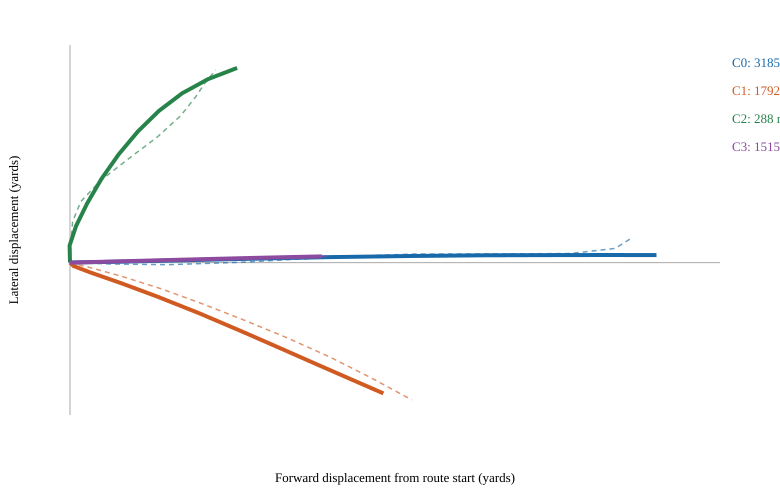

In [11]:
class SVG:
    def __init__(self, markup): self.markup = markup
    def _repr_svg_(self): return self.markup

palette = ["#1769aa", "#d05b22", "#27834a", "#8c4b9f", "#c49a00", "#117c83", "#b23b53", "#555555"]
width, height = 780, 500
left, top, plot_w, plot_h = 70, 45, 650, 370
x_min, x_max, y_min, y_max = 0.0, 22.0, -14.0, 20.0
def sx(x): return left + (x - x_min) / (x_max - x_min) * plot_w
def sy(y): return top + plot_h - (y - y_min) / (y_max - y_min) * plot_h

lines = [f'<rect width="{width}" height="{height}" fill="white"/>']
lines += [f'<line x1="{left}" y1="{sy(0)}" x2="{left+plot_w}" y2="{sy(0)}" stroke="#aaa"/>',
          f'<line x1="{sx(0)}" y1="{top}" x2="{sx(0)}" y2="{top+plot_h}" stroke="#aaa"/>']
for i, summary in enumerate(CLUSTER_SUMMARIES):
    color = palette[i % len(palette)]
    mean_path = json.loads(summary["mean_path"])
    rep_path = json.loads(summary["representative_path"])
    mean_points = " ".join(f"{sx(x):.1f},{sy(y):.1f}" for x, y in mean_path)
    rep_points = " ".join(f"{sx(x):.1f},{sy(y):.1f}" for x, y in rep_path)
    lines.append(f'<polyline points="{mean_points}" fill="none" stroke="{color}" stroke-width="4"/>')
    lines.append(f'<polyline points="{rep_points}" fill="none" stroke="{color}" stroke-width="1.5" stroke-dasharray="5,4" opacity="0.65"/>')
    lines.append(f'<text x="{left+plot_w+12}" y="{top+22+i*28}" fill="{color}" font-size="13">C{summary["cluster_id"]}: {summary["route_count"]} routes</text>')
lines += [f'<text x="{left+plot_w/2}" y="{height-18}" text-anchor="middle" font-size="13">Forward displacement from route start (yards)</text>',
          f'<text x="18" y="{top+plot_h/2}" transform="rotate(-90 18 {top+plot_h/2})" text-anchor="middle" font-size="13">Lateral displacement (yards)</text>']
cluster_paths = SVG(f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">{"".join(lines)}</svg>')
cluster_paths

In [12]:
CLUSTER_SUMMARIES

[{'cluster_id': '0', 'route_count': '3185', 'route_share': '0.156013', 'representative_gameId': '2021091910', 'representative_playId': '1290', 'representative_nflId': '44896', 'representative_name': 'Chris Godwin', 'representative_path': '[[0.0,0.0],[0.377,-0.029],[1.416,-0.122],[3.329,-0.19],[5.844,0.044],[8.635,0.465],[11.554,0.786],[14.463,0.794],[16.936,0.836],[18.454,1.308],[18.95,2.16]]', 'mean_path': '[[0.0,0.0],[0.2764,0.0194],[1.4649,0.0817],[3.519,0.2013],[6.0706,0.3572],[8.8017,0.5065],[11.4896,0.6138],[14.0022,0.6707],[16.2598,0.697],[18.2173,0.7039],[19.8501,0.6914]]'}, {'cluster_id': '1', 'route_count': '1792', 'route_share': '0.087779', 'representative_gameId': '2021102404', 'representative_playId': '742', 'representative_nflId': '46113', 'representative_name': 'Dante Pettis', 'representative_path': '[[0.0,0.0],[0.169,-0.104],[0.802,-0.536],[1.823,-1.317],[3.076,-2.396],[4.435,-3.735],[5.864,-5.25],[7.33,-6.887],[8.788,-8.658],[10.188,-10.579],[11.57,-12.61]]', 'mean_pat

## Interpretation

Geometry materially improves retrospective route-level prediction: OOF RMSE falls from 1.869 to 1.749 and R² rises from 0.508 to 0.569, with lower RMSE in all five folds. However, receiver split-half Pearson reliability falls from 0.452 to 0.262 (paired difference -0.190; 95% bootstrap interval -0.315 to 0.037). The interval includes zero, so the point estimate is concerning but uncertain; Spearman reliability also declines slightly with an interval spanning zero.

The route-family sweep selects k=4 by silhouette (about 0.409), but mean pairwise ARI is only about 0.60. Cluster sizes are highly imbalanced and the curves mainly separate broad movement patterns and route extent. Treat these as exploratory visual groupings, not dependable route labels.

Because the geometry includes the full realized path through release, the prediction gain is not evidence of a better snap-time forecast. Conditioning on route execution can also remove between-route receiver signal from SOE. Keep geometry and clusters experimental; the existing dynamic model remains the preferred player-evaluation score pending further temporal and season-level validation.